<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_6_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years. https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u (1).csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
df = df.dropna()

In [ ]:
df['Rating'] = (df['Rating'].str.replace('/10','').astype(float))

In [ ]:
median_rev = df['$Worldwide'].median()
df['High_Revenue'] = (df['$Worldwide'] > median_rev).astype(int)

In [ ]:
X = df[['Year','Rating','Vote_Count']]
y = df['High_Revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Decision Tree


In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)
pred_tree = tree.predict(X_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,pred_tree))
print("Precision:",precision_score(y_test,pred_tree))
print("Recall:",recall_score(y_test,pred_tree))
print("F1:",f1_score(y_test,pred_tree))

Accuracy: 0.7
Precision: 0.70042194092827
Recall: 0.694560669456067
F1: 0.6974789915966386


Decision Tree Plot

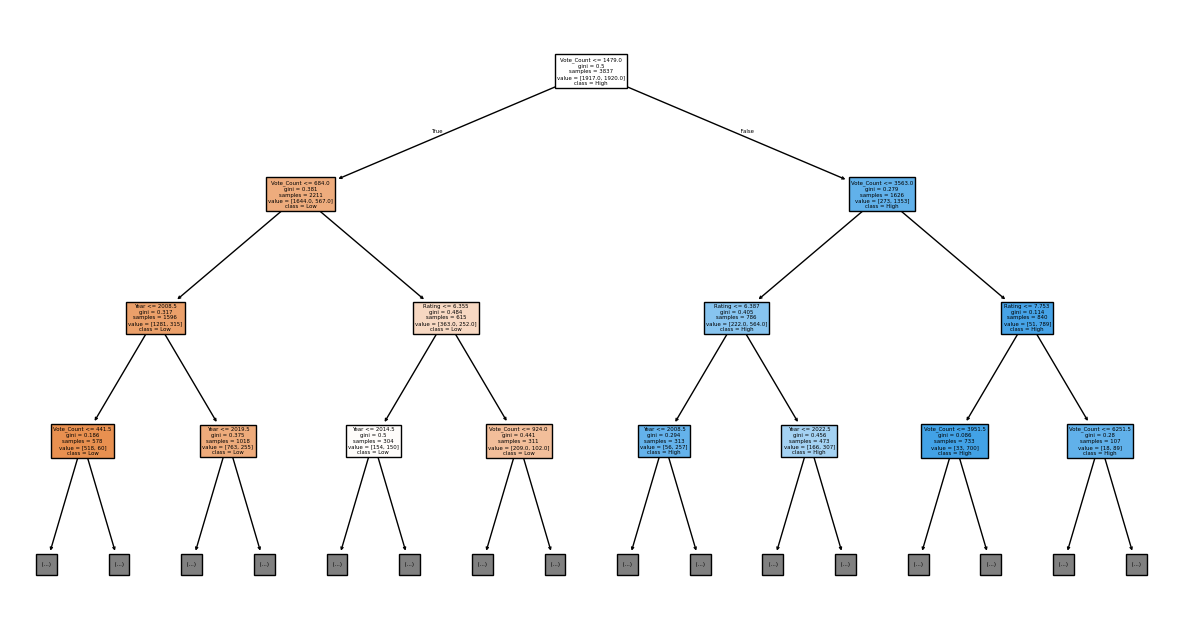

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X.columns, class_names=["Low","High"], filled=True, max_depth=3)
plt.show()

Hyperparameter Tuning

In [ ]:
params = {'max_depth':[3,5,7,None],'min_samples_split':[2,5,10]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5)
grid.fit( X_train, y_train)
best_tree = grid.best_estimator_

Random Forest

In [ ]:
forest = RandomForestClassifier(random_state=42)
forest.fit( X_train, y_train)
pred_forest = forest.predict( X_test)

In [ ]:
params = {'n_estimators':[50,100,200],'max_depth':[3,5,None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),params,cv=5)
rf_grid.fit(X_train,y_train)
best_forest = rf_grid.best_estimator_
pred_best = best_forest.predict(X_test)

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_forest.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
print(importance)

      Feature  Importance
2  Vote_Count    0.791153
0        Year    0.123230
1      Rating    0.085616


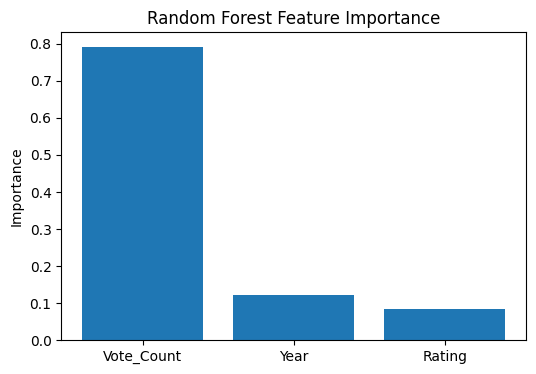

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(importance["Feature"],importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

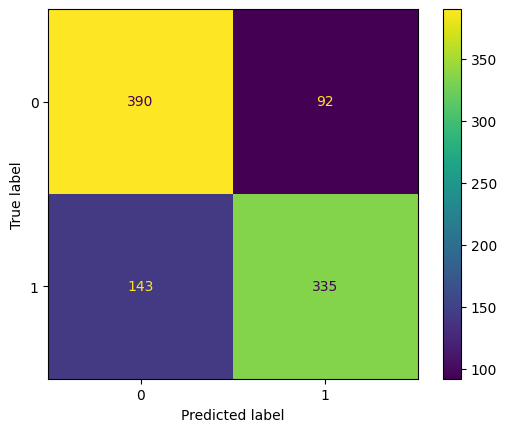

In [ ]:
cm = confusion_matrix(y_test, pred_best)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()